In [6]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Milestone 1: Data Selection and EDA

In [13]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nullify the warning message
import warnings
warnings.filterwarnings('ignore')

# Narrative

The biggest sport in the history of the world is soccer. No other sport brings in more global money, attention, criticism, and prestige than soccer. All the attention paid to soccer is what drives mountains of money to be poured into individual clubs, and countries, to find the next 'Wunderkid' that will lead the team to victory. However, all the money in the world would be wasted unless you could determine which attributes lead to a top-tier soccer player. That is why I have been given a list of the 100 top-tier soccer players from 2018 to determine which attribute are most correlated to value as a player. Once the features that predict top value for a soccer player have been extracted, teams/clubs/countries can use this information to scoure the globe to find the next Wunderkid before their opposition does.

# Importing Data & Clean

In [14]:
# Importing soccer dataset
df_m1 = pd.read_csv("soccer_player_value_2018.csv")

# Dropping columns not necessary for data exploration
cols_to_drop = ['Unnamed: 0', 'Name']

# Dropping columns from dataframe
df_m1 = df_m1.drop(cols_to_drop, axis = 1)


# Graph 1

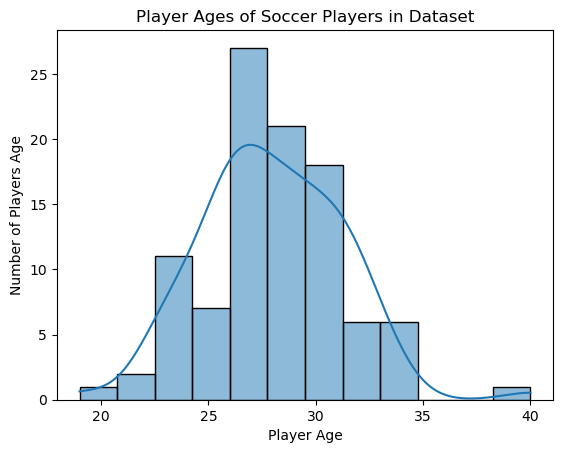

In [15]:
# Showing distribution of players age
sb.histplot(df_m1['Age'], kde = True)
plt.title("Player Ages of Soccer Players in Dataset")
plt.xlabel("Player Age")
plt.ylabel("Number of Players Age")
plt.show()

**Graph 1 Explanation:** \
Graph showing the age distribution of soccer players. For the exploratory data phase this is useful to see what the age of a player is, but doesn't necessarily impact the value of said player when using current physical metrics.

# Graph 2

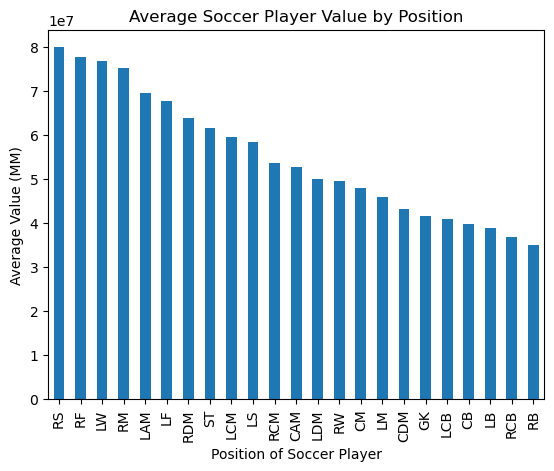

In [6]:
# Showing average value by position from dataset using bar graph
pos_val = df_m1.groupby('Position')['Value'].mean().sort_values(ascending = False)
pos_val.plot(kind = 'bar')

# Adding graph information
plt.title("Average Soccer Player Value by Position")
plt.xlabel("Position of Soccer Player")
plt.ylabel("Average Value (MM)")
plt.show()

**Graph 2 Explanation:** \
Showing a breakdown of the number of players in dataset to see which positions have a higher value. We can see that RS, RF, and LW are higher value positions with LB, RCB, RB being on the lower end. This information can lead to teams building around positions and which positions should be prioritized value-wise.

# Graph 3

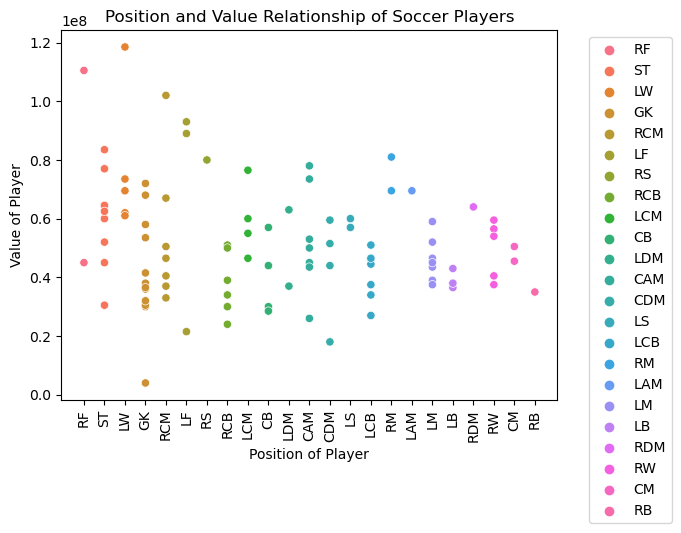

In [11]:
# Showering relationship between wage and value
sb.scatterplot(data = df_m1, x = 'Position', y = 'Value', hue = 'Position')

# Plotting data with titles
plt.title("Position and Value Relationship of Soccer Players")
plt.xlabel("Position of Player")

# Make xlabel vertical
plt.xticks(rotation = 'vertical')
plt.ylabel("Value of Player")

# Place legend of graph outside plot for easier readability
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.show()

**Graph 3 Explanation:** \
Graph showing the position of players and their value from the dataset. This is to show a distribution of the players' positions and value of the player.

# Graph 4

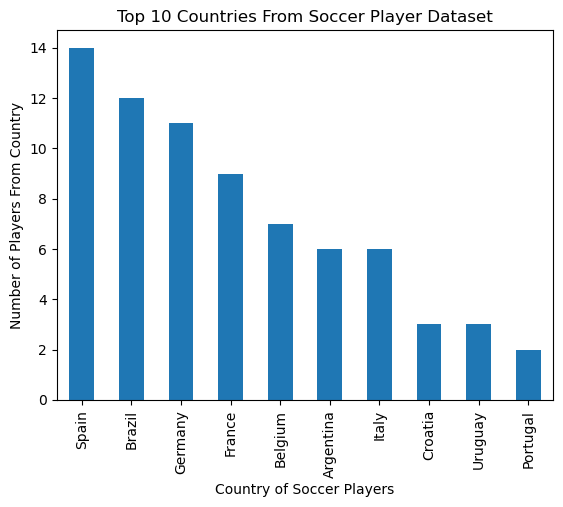

In [12]:
# Showing the top 10 countries distribution of the players from dataset
top_cntry = df_m1['Nationality'].value_counts().head(10)

# Plotting top 10 countries
top_cntry.plot(kind = 'bar')

# Adding plot data
plt.title("Top 10 Countries From Soccer Player Dataset")
plt.xlabel("Country of Soccer Players")
plt.ylabel("Number of Players From Country")
plt.show()

**Graph 4 Explanation:** \
Graph is showing the distribution of players from their respective countries. Would not be useful for the data model, but does show which country is contributing most to the top 100 players.

# Milestone 2: Data Preparation

In [13]:
# Importing packages
import pandas as pd
import numpy as np

# Data Import

In [14]:
# Importing soccer dataset
df = pd.read_csv("soccer_player_value_2018.csv")

# Dropping Features

In [15]:
# Filtering dataframe to remove the GK position as this is not a position that a team would use the physical attributes...
# in scouting whether a player adds value to the club
df = df.query("Position != 'GK'")

# Dropping unnecessary columns that are not used to predict value of soccer player
# Since goal keepers are not the physical/active/athletic players I am dropping the GK position...
# as well as any goal keeper metrics so they don't produce any extra noise in model
# Also, dropping Nationality, Club, Age, Wage, and Position as these are not physical skills in predicting player value
cols_to_drop = ['Unnamed: 0', 'Name', 'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
               'Nationality', 'Club', 'Position', 'Wage', 'Age']

# Dropping columns from dataframe
df = df.drop(cols_to_drop, axis = 1)


In [16]:
# Confirming columns have been dropped
df.columns

Index(['Value', 'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing',
       'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing',
       'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions',
       'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
       'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
       'Composure', 'Marking', 'StandingTackle', 'SlidingTackle'],
      dtype='object')

**Explanation**: \
The GK position is not the athletic player that a club would think of when adding value and using physical attributes, so this position has been removed as well as the goalkeeper metrics (The 'GK*' columns). The 'Unnamed: 0' and 'Name' columns are not required for analysis in determing player value and can safely be dropped. The 'Nationality', 'Club', and 'Position' have also been dropped as these are not physical attributes of a player so cannot be used in determining value of said player and what they bring.

# Milestone 3: Model Building and Evaluation

**Algorithms to be used:** \
The algorithms that will be used to build models for this analysis of soccer player data will be linear regression and random forest regression. Since we have a dataset of soccer players with their graded skill levels, along with other feature data, we can use this to predict the numerical value of 'Value' from the dataset to determine which model would be best to predict a high-value soccer player. Once we have created the model we can then evaluate using MSE and R^2 to determine what model would be the best fit for this data and to determine which features are best to use to predict value of a soccer player.

**R^2**, or the coefficient of determination, is used to evaluate whether the model is a good fit for the data. We are looking for this number to be higher than the other model when comparing. \
The **MSE** is used to evaluate how predictive the model performs. The lower the value of MSE of a model determines that the predictions are closer to the true values, so lower is better when we're comparing these models.

Once the best model has been selected for our regression analysis, we can then determine which top-5 features are best to be used in predicting the numerical value of a high-value soccer player.

**Feature/Target preparation**

In [17]:
# Separating the features/target variables
x = df.drop('Value', axis = 1) # Features
y = df['Value'] # Target

# Scaling features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

**Train/Test Dataset Creation**

In [18]:
# Splitting the data into training/test sets for model building
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2)

**Linear Regression**

In [19]:
# Starting with linear regression model to predict value from features
lin_reg_model = LinearRegression()

# Fitting model with training data
lin_reg_model.fit(x_train, y_train)

LinearRegression()

In [20]:
# Predictions of linear regression model
y_pred_lin_reg = lin_reg_model.predict(x_test)

# Evaluate linear regression model predictions
lin_reg_mse = mean_squared_error(y_test, y_pred_lin_reg)
lin_reg_r2 = r2_score(y_test, y_pred_lin_reg)

# Printing output
print("Linear Regression MSE:", lin_reg_mse)
print("Linear Regression R^2:", lin_reg_r2)

Linear Regression MSE: 233856492346734.03
Linear Regression R^2: 0.6473639220707705


**Linear Regression Explanation**: \
The MSE being high (will be high for these examples) and the R^2 being low would make it seem that this linear regression model would not be a good fit for the dataset. However, cannot make a choice until we view the random forest regressor.

**Random Forest Regressor**

In [21]:
# Creating random forest regressor model
ran_for_model = RandomForestRegressor(n_estimators = 100)

# Fitting model
ran_for_model.fit(x_train, y_train)

RandomForestRegressor()

In [22]:
# Predictions for random forest regressor model
y_pred_ran_for = ran_for_model.predict(x_test)

# Evaluating the random forest regressor model
ran_for_mse = mean_squared_error(y_test, y_pred_ran_for)
ran_for_r2 = r2_score(y_test, y_pred_ran_for)

# Printing output
print("Random Forest Regressor MSE:", ran_for_mse)
print("Random Forest Regressor R^2:", ran_for_r2)

Random Forest Regressor MSE: 221864295833333.34
Random Forest Regressor R^2: 0.6654471538074893


**Random Forest Regressor Explanation:** \
The MSE is very high (but lower when compared to linear regression) and the R^2 being higher would make it seem that random forest regression model is a better model to use when trying to find features that are best to use to predict value of a soccer player.

**Evaluating Linear Regression vs Random Forest Regressor** \
When comparing the MSE and R^2 of linear regression to random forest regression we can make the conclusion that random forest regression is better to use when wanting to predict the highest value player from the dataset using the features provided. Comparing the linear regression model to the random forest regressor model the coefficient of determination is higher for random forest regressor. This is saying that the goodness of fit is better for the random forest regressor model so that one will be selected for further/future analysis of this data. Also, the MSE being lower for the random forest regressor is also adding that this model predictions are closer to the true values.

**Extract which features from random forest regressor are contributing more to the value**

In [23]:
# Feature Importance using Random Forest
feature_importances = pd.Series(ran_for_model.feature_importances_, index = df.drop('Value', axis = 1).columns)
feature_importances = feature_importances.sort_values(ascending = False)

In [60]:
# Top 5 features that contribute most to determing value of soccer player
feature_importances[:5]

Reactions      0.244821
Dribbling      0.088714
BallControl    0.082038
LongShots      0.064355
Finishing      0.054348
dtype: float64

Using the feature_importances from random forest regression the top columns to use to predict the value of a future player are Reactions, Dribbling, BallControl, Longshots, and Finishing. When a club focuses on these attributes they have a higher chance of finding a high-value player than when focusing on different attributes. 